# Analyse de donnees - House Prices (baseline lineaire)

Objectif de ce notebook:
- travailler uniquement avec `train.csv` pour analyser la cible `SalePrice`
- comparer 10 variables candidates (dont cave, taille, age, qualite globale, emplacement)
- retenir 5 variables simples et robustes pour un futur modele baseline

Important: aucun entrainement de modele dans ce notebook.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)


In [2]:
# Chargement des donnees (train uniquement)
BASE_DIR = Path(".")
DATA_DIR = BASE_DIR / "Data"

train_df = pd.read_csv(DATA_DIR / "train.csv")

print(f"train shape: {train_df.shape}")
print(f"Nombre de colonnes: {len(train_df.columns)}")
print(f"SalePrice present: {'SalePrice' in train_df.columns}")

train_df.head(3)


train shape: (1460, 81)
Nombre de colonnes: 81
SalePrice present: True


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


## Dictionnaire des variables (extrait rapide)

On affiche seulement quelques lignes pertinentes du `data_description.txt`.


In [3]:
desc_path = DATA_DIR / "data_description.txt"
desc_text = desc_path.read_text(encoding="utf-8", errors="ignore")

keywords = [
	"SalePrice",
	"Neighborhood",
	"OverallQual",
	"GrLivArea",
	"TotalBsmtSF",
	"YearBuilt",
	"YrSold",
	"GarageCars",
	"LotArea",
	"KitchenQual",
	"BsmtQual",
]

for line in desc_text.splitlines():
	if any(k in line for k in keywords):
		print(line)


LotArea: Lot size in square feet
Neighborhood: Physical locations within Ames city limits
OverallQual: Rates the overall material and finish of the house
YearBuilt: Original construction date
BsmtQual: Evaluates the height of the basement
TotalBsmtSF: Total square feet of basement area
GrLivArea: Above grade (ground) living area square feet
KitchenQual: Kitchen quality
GarageCars: Size of garage in car capacity
YrSold: Year Sold (YYYY)


## Qualite globale des donnees


In [4]:
missing_pct = train_df.isna().mean().mul(100).sort_values(ascending=False)

print("Top 15 colonnes avec le plus de valeurs manquantes:")
display(missing_pct.head(15).to_frame("missing_%"))

print("\nStatistiques de SalePrice:")
display(train_df["SalePrice"].describe())


Top 15 colonnes avec le plus de valeurs manquantes:


,missing_%
PoolQC,99.520548
MiscFeature,96.301370
Alley,93.767123
Fence,80.753425
MasVnrType,59.726027
FireplaceQu,47.260274
LotFrontage,17.739726
GarageQual,5.547945
GarageFinish,5.547945
GarageType,5.547945



Statistiques de SalePrice:


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

## Distribution de la cible

On compare la distribution brute et la version log(1 + prix).


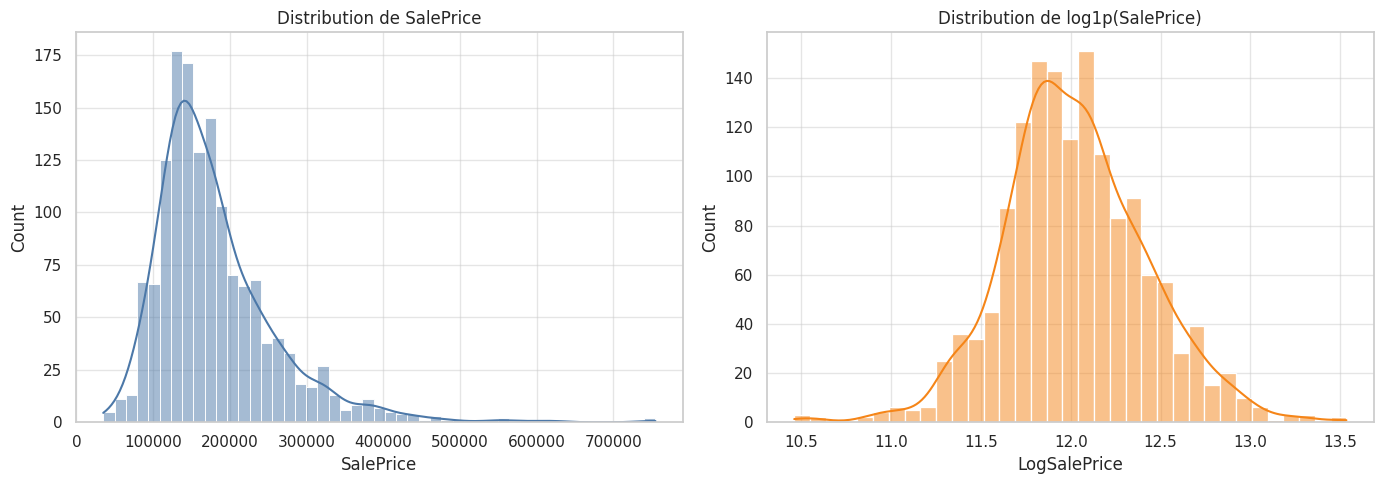

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train_df["SalePrice"], kde=True, ax=axes[0], color="#4C78A8")
axes[0].set_title("Distribution de SalePrice")

train_df["LogSalePrice"] = np.log1p(train_df["SalePrice"])
sns.histplot(train_df["LogSalePrice"], kde=True, ax=axes[1], color="#F58518")
axes[1].set_title("Distribution de log1p(SalePrice)")

plt.tight_layout()
plt.show()


In [6]:
# Variable age de la maison au moment de la vente
train_df["AgeAtSale"] = train_df["YrSold"] - train_df["YearBuilt"]

# 10 candidates = 5 conseillees + 5 supplementaires
candidates = [
	# Conseillees par le prof
	"TotalBsmtSF",   # cave (taille cave)
	"GrLivArea",     # taille habitable
	"AgeAtSale",     # age
	"OverallQual",   # qualite globale
	"Neighborhood",  # emplacement
	# 5 autres proposees
	"GarageCars",
	"LotArea",
	"1stFlrSF",
	"YearRemodAdd",
	"KitchenQual",
]

print("Variables candidates:", candidates)


Variables candidates: ['TotalBsmtSF', 'GrLivArea', 'AgeAtSale', 'OverallQual', 'Neighborhood', 'GarageCars', 'LotArea', '1stFlrSF', 'YearRemodAdd', 'KitchenQual']


## Analyse des 10 variables candidates

Signal + praticite:
- correlations de Spearman et de Pearson avec `LogSalePrice` pour les variables numeriques
- missing (%)
- cardinalite pour les categories


In [7]:
numeric_candidates = [c for c in candidates if c in train_df.columns and pd.api.types.is_numeric_dtype(train_df[c])]
categorical_candidates = [c for c in candidates if c in train_df.columns and c not in numeric_candidates]

rows = []
for col in candidates:
	s = train_df[col]
	miss = s.isna().mean() * 100
	if col in numeric_candidates:
		corr_s_raw = train_df[[col, "LogSalePrice"]].corr(method="spearman").iloc[0, 1]
		corr_p_raw = train_df[[col, "LogSalePrice"]].corr(method="pearson").iloc[0, 1]
		corr_s = pd.to_numeric(corr_s_raw, errors="coerce")
		corr_p = pd.to_numeric(corr_p_raw, errors="coerce")
		rows.append(
			{
				"variable": col,
				"type": "numerique",
				"missing_%": round(miss, 2),
				"cardinalite": int(s.nunique(dropna=True)),
				"spearman_logprice": round(corr_s, 3) if pd.notna(corr_s) else np.nan,
				"pearson_logprice": round(corr_p, 3) if pd.notna(corr_p) else np.nan,
			}
		)
	else:
		rows.append(
			{
				"variable": col,
				"type": "categorielle",
				"missing_%": round(miss, 2),
				"cardinalite": int(s.nunique(dropna=True)),
				"spearman_logprice": np.nan,
				"pearson_logprice": np.nan,
			}
		)

profile_df = pd.DataFrame(rows).sort_values(["type", "missing_%", "variable"])
display(profile_df)


,variable,type,missing_%,cardinalite,spearman_logprice,pearson_logprice
9,KitchenQual,categorielle,0.0,4,NaN,NaN
4,Neighborhood,categorielle,0.0,25,NaN,NaN
7,1stFlrSF,numerique,0.0,753,0.575,0.597
2,AgeAtSale,numerique,0.0,122,-0.650,-0.587
5,GarageCars,numerique,0.0,5,0.691,0.681
1,GrLivArea,numerique,0.0,861,0.731,0.701
6,LotArea,numerique,0.0,1073,0.456,0.257
3,OverallQual,numerique,0.0,10,0.810,0.817
0,TotalBsmtSF,numerique,0.0,721,0.603,0.612
8,YearRemodAdd,numerique,0.0,61,0.571,0.566


## Variables numeriques: correlation avec la cible (Spearman + Pearson)


,spearman_logprice,pearson_logprice
OverallQual,0.809829,0.817185
GrLivArea,0.731310,0.700927
GarageCars,0.690711,0.680625
AgeAtSale,-0.650120,-0.587290
TotalBsmtSF,0.602725,0.612134
1stFlrSF,0.575408,0.596981
YearRemodAdd,0.571159,0.565608
LotArea,0.456461,0.257320


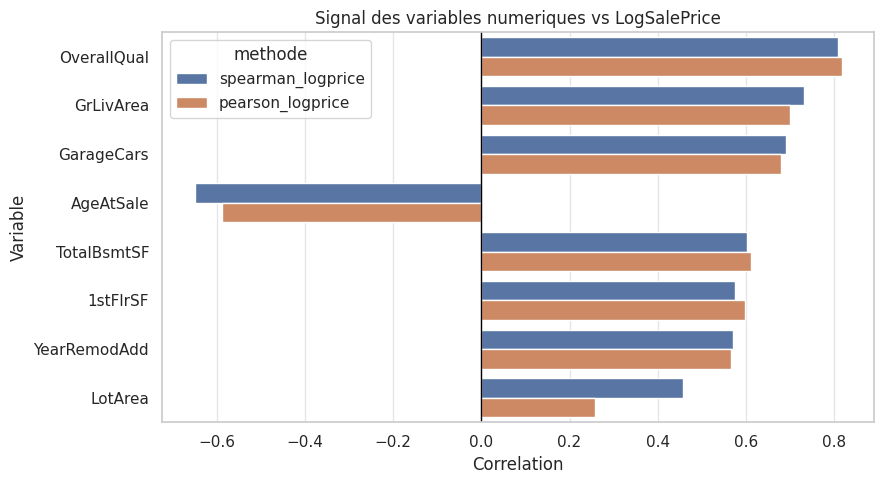

In [8]:
corr_target_spearman = (
	train_df[numeric_candidates + ["LogSalePrice"]]
	.corr(method="spearman")["LogSalePrice"]
	.drop("LogSalePrice")
)

corr_target_pearson = (
	train_df[numeric_candidates + ["LogSalePrice"]]
	.corr(method="pearson")["LogSalePrice"]
	.drop("LogSalePrice")
)

corr_target = pd.concat(
	[
		corr_target_spearman.rename("spearman_logprice"),
		corr_target_pearson.rename("pearson_logprice"),
	],
	axis=1,
)

corr_target["abs_mean"] = corr_target.abs().mean(axis=1)
corr_target = corr_target.sort_values("abs_mean", ascending=False).drop(columns="abs_mean")

display(corr_target)

plot_df = (
	corr_target
	.reset_index()
	.rename(columns={"index": "variable"})
	.melt(id_vars="variable", var_name="methode", value_name="correlation")
)

plt.figure(figsize=(9, 5))
sns.barplot(data=plot_df, x="correlation", y="variable", hue="methode")
plt.axvline(0, color="black", linewidth=1)
plt.title("Signal des variables numeriques vs LogSalePrice")
plt.xlabel("Correlation")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()


## Variables categorielles: effet sur le prix (mediane)



--- Neighborhood ---
Modalites: 25
Missing: 0.00%


,median_SalePrice_top
Neighborhood,
NridgHt,315000.0
NoRidge,301500.0
StoneBr,278000.0
Timber,228475.0
Somerst,225500.0
Veenker,218000.0
Crawfor,200624.0
ClearCr,200250.0


,median_SalePrice_bottom
Neighborhood,
Blueste,137500.0
Sawyer,135000.0
BrkSide,124300.0
Edwards,121750.0
OldTown,119000.0
BrDale,106000.0
IDOTRR,103000.0
MeadowV,88000.0


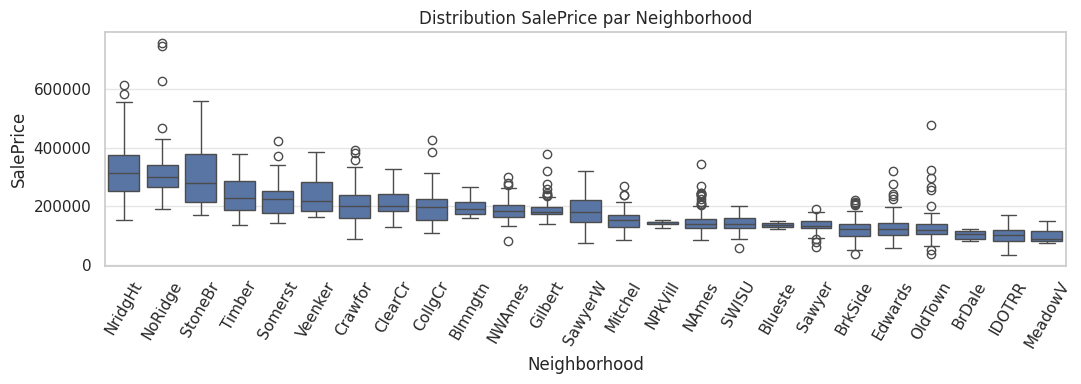


--- KitchenQual ---
Modalites: 4
Missing: 0.00%


,median_SalePrice_top
KitchenQual,
Ex,316750.0
Gd,201400.0
TA,137000.0
Fa,115000.0


,median_SalePrice_bottom
KitchenQual,
Ex,316750.0
Gd,201400.0
TA,137000.0
Fa,115000.0


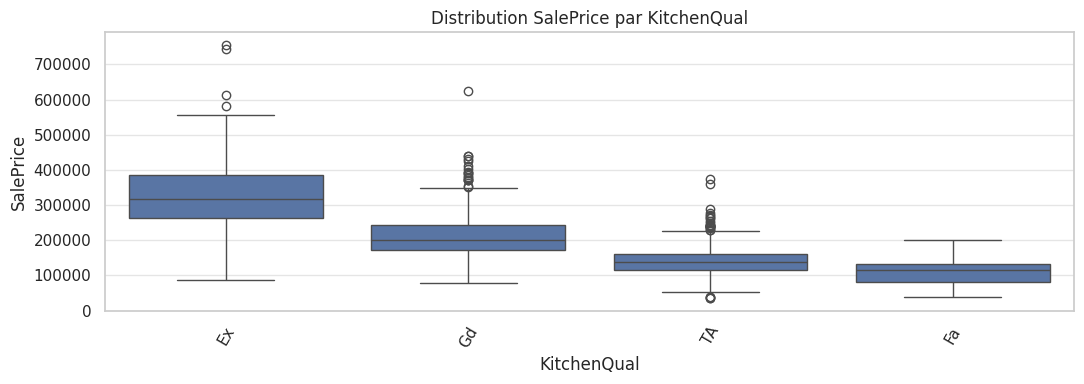

In [9]:
for col in categorical_candidates:
	med = (
		train_df.groupby(col, dropna=False)["SalePrice"]
		.median()
		.sort_values(ascending=False)
	)

	print(f"\n--- {col} ---")
	print(f"Modalites: {train_df[col].nunique(dropna=True)}")
	print(f"Missing: {train_df[col].isna().mean()*100:.2f}%")
	display(med.head(8).to_frame("median_SalePrice_top"))
	display(med.tail(8).to_frame("median_SalePrice_bottom"))

	plt.figure(figsize=(11, 4))
	order = med.index
	sns.boxplot(data=train_df, x=col, y="SalePrice", order=order)
	plt.xticks(rotation=60)
	plt.title(f"Distribution SalePrice par {col}")
	plt.tight_layout()
	plt.show()


## Redondance entre variables numeriques (colinearite)

On evite de garder des variables trop redondantes dans un baseline lineaire simple.


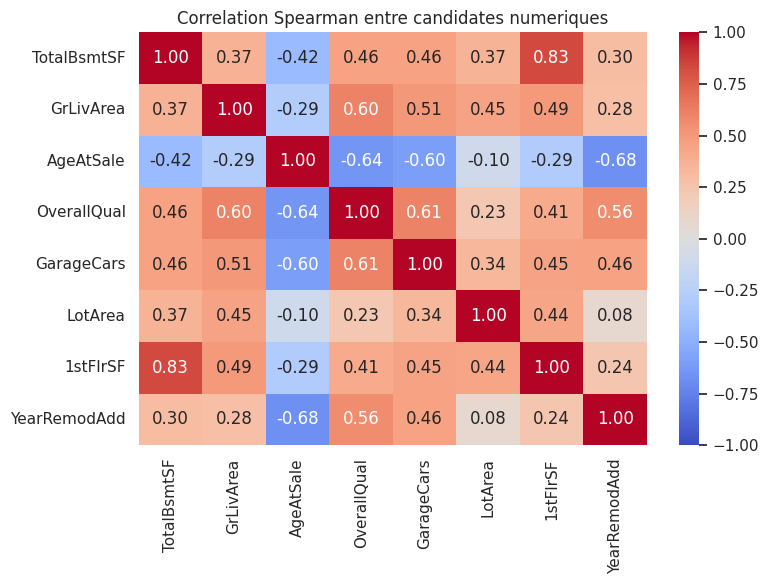

Paires avec |corr| >= 0.75:
[('TotalBsmtSF', '1stFlrSF', np.float64(0.829))]


In [10]:
corr_num = train_df[numeric_candidates].corr(method="spearman")

plt.figure(figsize=(8, 6))
sns.heatmap(corr_num, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Spearman entre candidates numeriques")
plt.tight_layout()
plt.show()

# Paires fortement correlees (seuil arbitraire 0.75)
high_pairs = []
for i, c1 in enumerate(numeric_candidates):
	for c2 in numeric_candidates[i + 1 :]:
		val_raw = corr_num.loc[c1, c2]
		if pd.isna(val_raw):
			continue
		val = pd.to_numeric(val_raw, errors="coerce")
		if pd.isna(val):
			continue
		if abs(val) >= 0.75:
			high_pairs.append((c1, c2, round(val, 3)))

print("Paires avec |corr| >= 0.75:")
print(high_pairs if high_pairs else "Aucune")


## Decision: 5 variables baseline retenues

Critere simple:
1. signal convergent (Spearman + Pearson) avec `LogSalePrice`
2. faible taux de missing
3. interpretation metier claire
4. redondance limitee

Selection finale proposee:
- `OverallQual`
- `GrLivArea`
- `TotalBsmtSF`
- `AgeAtSale`
- `Neighborhood`

Variables non retenues pour le baseline (mais pertinentes):
- `GarageCars` (assez proche de qualite/age)
- `1stFlrSF` (redondance partielle avec `GrLivArea` et `TotalBsmtSF`)
- `YearRemodAdd` (information proche de l'age/remodel)
- `LotArea` (signal plus faible)
- `KitchenQual` (utile, mais baseline deja assez riche avec 5 features)


In [11]:
decision_table = pd.DataFrame(
	{
		"variable": candidates,
		"retenue_baseline": [
			True,   # TotalBsmtSF
			True,   # GrLivArea
			True,   # AgeAtSale
			True,   # OverallQual
			True,   # Neighborhood
			False,  # GarageCars
			False,  # LotArea
			False,  # 1stFlrSF
			False,  # YearRemodAdd
			False,  # KitchenQual
		],
		"raison_courte": [
			"Signal fort + cave (reco prof)",
			"Signal fort + taille habitable",
			"Signal fort + age maison",
			"Signal tres fort + qualite globale",
			"Effet emplacement net sur le prix",
			"Pertinente mais non prioritaire en top 5",
			"Signal plus faible",
			"Redondance partielle avec surface totale",
			"Info partiellement couverte par AgeAtSale",
			"Pertinente mais categorie deja couverte",
		],
	}
)

display(decision_table)

baseline_features = decision_table.loc[decision_table["retenue_baseline"], "variable"].tolist()
print("Features baseline finales:", baseline_features)


,variable,retenue_baseline,raison_courte
0,TotalBsmtSF,True,Signal fort + cave (reco prof)
1,GrLivArea,True,Signal fort + taille habitable
2,AgeAtSale,True,Signal fort + age maison
3,OverallQual,True,Signal tres fort + qualite globale
4,Neighborhood,True,Effet emplacement net sur le prix
5,GarageCars,False,Pertinente mais non prioritaire en top 5
6,LotArea,False,Signal plus faible
7,1stFlrSF,False,Redondance partielle avec surface totale
8,YearRemodAdd,False,Info partiellement couverte par AgeAtSale
9,KitchenQual,False,Pertinente mais categorie deja couverte


Features baseline finales: ['TotalBsmtSF', 'GrLivArea', 'AgeAtSale', 'OverallQual', 'Neighborhood']


## Conclusion

La double lecture Spearman + Pearson confirme un noyau de variables robustes pour une baseline lineaire.

Pour la suite (hors de ce notebook), tu peux utiliser ces 5 variables:

`['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'AgeAtSale', 'Neighborhood']`

Le notebook reste volontairement simple et oriente analyse pour justifier ce choix.
